# Heat equation with Galerkin-methods

We now want to solve the 1D heat equation $$\partial_x^2 u(t,x) = \partial_t u(t,x)$$ with the Galerkin method. Using again a set of basis functions $\phi_i$ we can derive the weak formulation of the problem as
$$\Delta u = \partial_t u \; \Leftrightarrow \; -\int_\Omega \nabla u \nabla \phi_i = \int_\Omega \partial_t u \phi_i \; \Leftrightarrow \; -\sum_j \int_\Omega c_j \nabla \phi_j \nabla \phi_i = \sum_j \phi_j \phi_i \partial_t c_j$$
In a matrix formulation this takes the form
$$M \dot{\mathbf{c}} = - A \mathbf{c}$$
Discretizing the time derivative we get
$$\frac{\mathbf{c}_{n+1} - \mathbf{c}_n}{\Delta t} \; \Rightarrow \; (M + \Delta t A) \mathbf{c}_{n+1} = M \mathbf{c}$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science", "grid"])

### Define basis functions

In [12]:
def phi(x, i, nodes, h):
    lower = nodes[i-1]
    mid   = nodes[i]
    upper = nodes[i+1]
    if x > upper or x < lower:
        return 0
    elif x <= mid:
        return (x - lower)/h
    else:
        return (upper - x)/h

### Equation solver

In [13]:
def solve_heat_equation(n, dt, T, u0, n_snapshots=10):
    nodes = np.linspace(-1, 1, n+1)
    nodes_int = nodes[1:-1]
    h = nodes[1] - nodes[0]
    m = n - 1

    A = np.zeros((m,m))
    M = np.zeros((m,m))
    for i in range(m):
        for j in range(m):
            if i == j:
                A[i,j] = 2 / h
                M[i,j] = 2 * h / 3
            if abs(i - j) == 1:
                A[i,j] = -1 / h
                M[i,j] = h / 6

    S = M + dt * A
    u = u0(nodes_int)

    # snapshot every k steps
    n_steps = int(T / dt)
    k = max(1, n_steps // n_snapshots)

    snapshots = [np.concatenate([[0], u, [0]])]
    times = [0.0]

    t = 0
    step = 0
    while t < T:
        rhs = M @ u
        u = np.linalg.solve(S, rhs)
        t += dt
        step += 1
        if step % k == 0:
            snapshots.append(np.concatenate([[0], u, [0]]))
            times.append(t)

    return nodes, snapshots, times

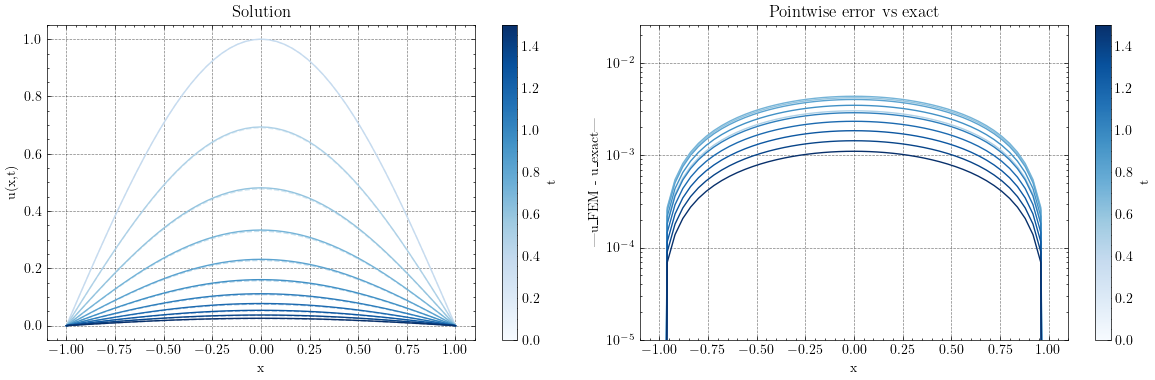

In [14]:
u0      = lambda x: np.cos(np.pi * x / 2)
u_exact = lambda x, t: np.exp(-np.pi**2 * t / 4) * np.cos(np.pi * x / 2)

n  = 50
dt = 0.01
T  = 1.5

nodes_c, snaps_c, times_c = solve_heat_equation(n, dt, T, u0, n_snapshots=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.Blues(np.linspace(0.25, 1, len(snaps_c)))

for i, (snap, t) in enumerate(zip(snaps_c, times_c)):
    axes[0].plot(nodes_c, snap, color=colors[i])
    axes[0].plot(nodes_c, u_exact(nodes_c, t), '--', color=colors[i], alpha=0.4)
    axes[1].plot(nodes_c, np.abs(snap - u_exact(nodes_c, t)), color=colors[i])

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=T))
plt.colorbar(sm, ax=axes[0], label='t')
plt.colorbar(sm, ax=axes[1], label='t')

axes[0].set_title('Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x,t)')
axes[1].set_title('Pointwise error vs exact')
axes[1].set_xlabel('x')
axes[1].set_ylabel('|u_FEM - u_exact|')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-5)

plt.tight_layout()
plt.show()

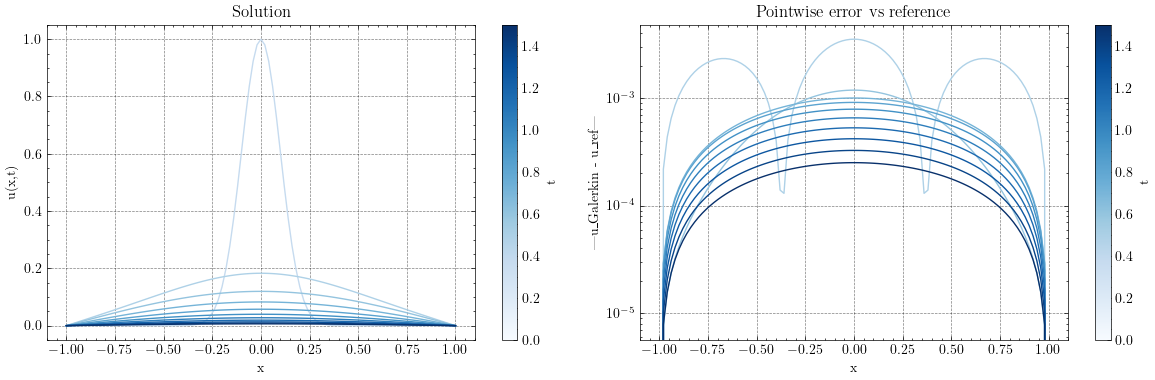

In [15]:
u0 = lambda x: np.exp(-50 * x**2)

n  = 100
dt = 0.01
T  = 1.5

nodes_ref, snaps_ref, times_ref = solve_heat_equation(500, 0.001, T, u0, n_snapshots=10)
nodes_c, snaps_c, times_c       = solve_heat_equation(n, dt, T, u0, n_snapshots=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.Blues(np.linspace(0.25, 1, len(snaps_c)))

for i, (snap, t) in enumerate(zip(snaps_c, times_c)):
    axes[0].plot(nodes_c, snap, color=colors[i])
    ref_interp = np.interp(nodes_c, nodes_ref, snaps_ref[i])
    axes[1].plot(nodes_c, np.abs(snap - ref_interp), color=colors[i])

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=T))
plt.colorbar(sm, ax=axes[0], label='t')
plt.colorbar(sm, ax=axes[1], label='t')

axes[0].set_title('Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x,t)')
axes[1].set_title('Pointwise error vs reference')
axes[1].set_xlabel('x')
axes[1].set_ylabel('|u_Galerkin - u_ref|')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()